In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

## Ideal Qubit Circuit — Exact Statevector Comparison

This notebook compares the qubit circuit's *exact* quantum state against the
analytical formula, using a noiseless statevector simulator (no measurement
shots, no sampling randomness). This isolates whether the circuit design
itself is correct, separate from any statistical sampling noise.

**Circuit design:**
- RY(2θ): prepares the flavor-mixed initial state
- RZ(φ), where φ = 2 × 1.27 × Δm² × (L/E): applies the relative phase
  accumulated during propagation
- RY(−2θ): reverses the mixing transformation, projecting back onto the
  flavor basis for readout
- Measurement (or exact probability extraction) gives the oscillation probability

Each RY gate corresponds physically to rotating between the flavor and mass
bases; the RZ gate encodes the phase difference between mass eigenstates
accumulated over the neutrino's flight path.

In [ ]:
!pip install qiskit qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


Qiskit version: 2.5.1
Exact statevector vs analytical: MAE = 6.80e-17, Max error = 3.33e-16


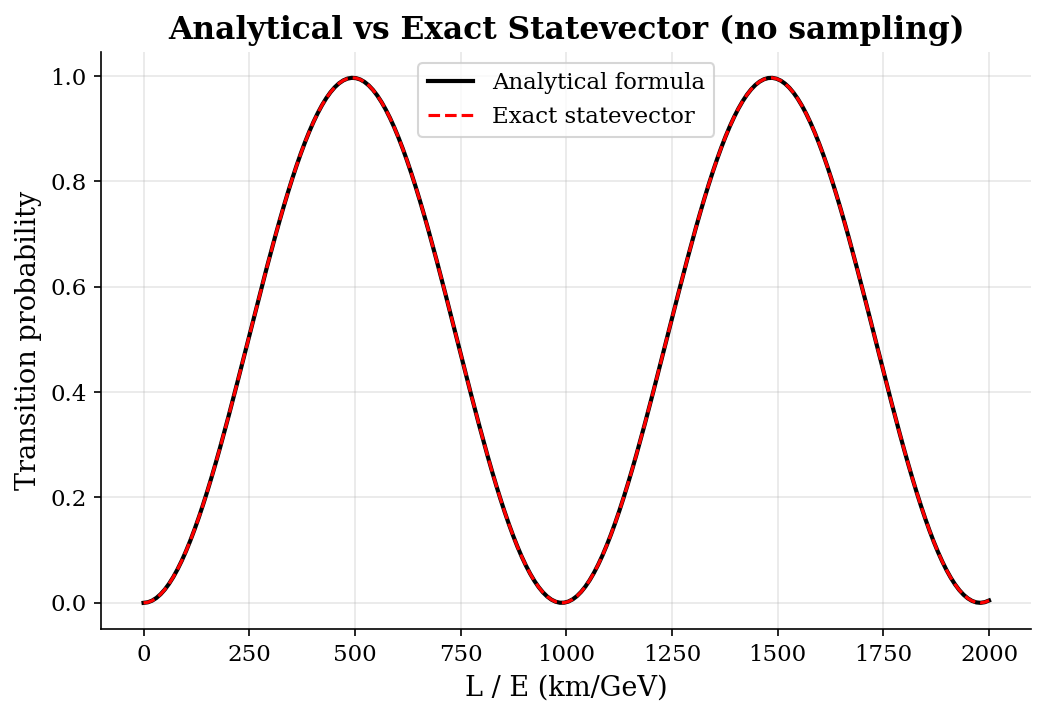

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

# Record versions for reproducibility
import qiskit
print("Qiskit version:", qiskit.__version__)

theta_23_deg = 43.3
theta = np.deg2rad(theta_23_deg)
delta_m2 = 2.5e-3

def exact_transition_probability(L_over_E, theta, delta_m2):
    phi = 2 * 1.27 * delta_m2 * L_over_E
    qc = QuantumCircuit(1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)

    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()  # [P(0), P(1)]
    return probs[1]  # P(1) = transition probability

L_over_E_vals = np.linspace(0.1, 2000, 200)
P_exact = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_vals])
P_classical = (np.sin(2*theta)**2) * (np.sin(1.27 * delta_m2 * L_over_E_vals)**2)

mae_exact = np.mean(np.abs(P_exact - P_classical))
max_err_exact = np.max(np.abs(P_exact - P_classical))
print(f"Exact statevector vs analytical: MAE = {mae_exact:.2e}, Max error = {max_err_exact:.2e}")

plt.figure(figsize=(8,5))
plt.plot(L_over_E_vals, P_classical, 'k-', linewidth=2, label="Analytical formula")
plt.plot(L_over_E_vals, P_exact, 'r--', linewidth=1.5, label="Exact statevector")
plt.xlabel("L / E (km/GeV)")
plt.ylabel("Transition probability")
plt.title("Analytical vs Exact Statevector (no sampling)")
plt.legend()
plt.grid(True)
plt.savefig("fig2_exact_statevector_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Visualize the circuit
example_qc = QuantumCircuit(1)
example_qc.ry(2*theta, 0)
example_qc.rz(1.0, 0)  # example phase value just for the diagram
example_qc.ry(-2*theta, 0)
example_qc.measure_all()
print(example_qc.draw(output='text'))

        ┌────────────┐┌───────┐┌─────────────┐ ░ ┌─┐
     q: ┤ Ry(1.5115) ├┤ Rz(1) ├┤ Ry(-1.5115) ├─░─┤M├
        └────────────┘└───────┘└─────────────┘ ░ └╥┘
meas: 1/══════════════════════════════════════════╩═
                                                  0 


### Physical meaning of each gate

- **RY(2θ)**: Rotates the qubit from the pure |0⟩ state into a superposition
  determined by the mixing angle θ. This mirrors how a neutrino is produced
  as a definite flavor state but is actually a quantum superposition of mass
  eigenstates — RY encodes that same flavor-to-mass basis mixing.

- **RZ(φ)**: Applies a phase rotation of φ = 2 × 1.27 × Δm² × (L/E) around
  the Z-axis. This represents the relative phase that accumulates between
  the two mass eigenstates as the neutrino propagates a distance L with
  energy E — a direct consequence of the two mass states having a mass
  difference Δm² and therefore evolving at slightly different rates.

- **RY(−2θ)**: Rotates back from the mass basis to the flavor basis — the
  physical analog of "detecting" the neutrino, i.e. asking which flavor
  it is now, after the phase has evolved. Measurement then reads out the
  probability of finding it in the *other* flavor state (transition
  probability) versus the original flavor (survival probability).

Random seed used: 42

Sampling results compared against EXACT statevector (not analytical formula directly):
  100 shots: MAE vs exact = 0.0302
  1000 shots: MAE vs exact = 0.0112
  8000 shots: MAE vs exact = 0.0034
  10000 shots: MAE vs exact = 0.0024


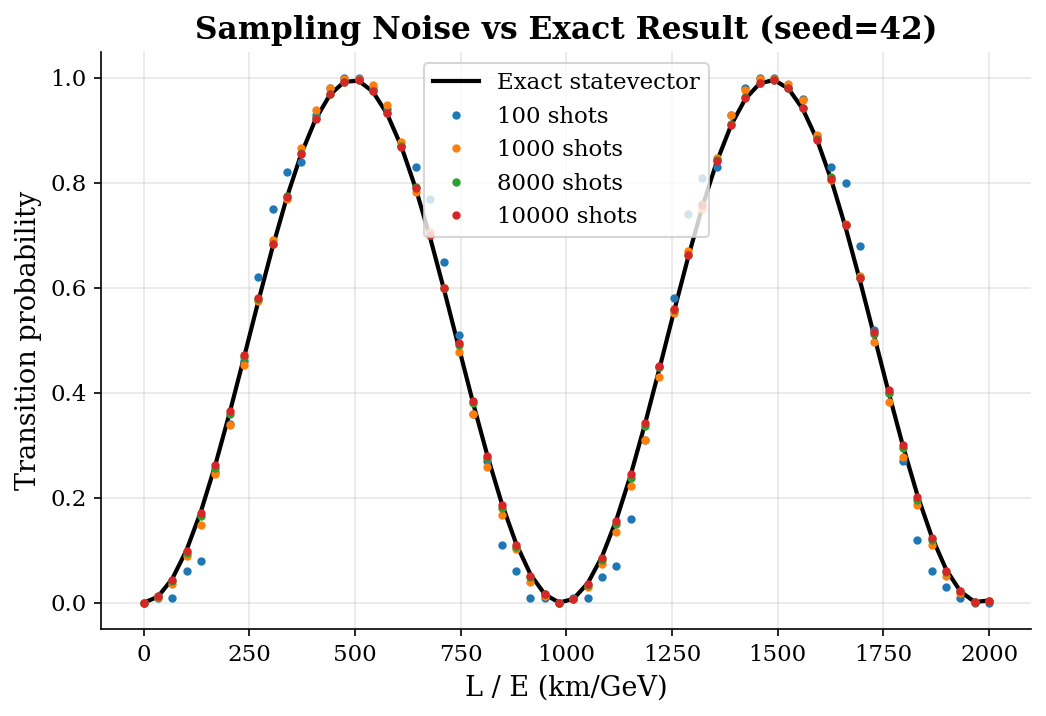

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile

def sampled_transition_probability(L_over_E, theta, delta_m2, shots, seed):
    phi = 2 * 1.27 * delta_m2 * L_over_E
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    qc.measure(0, 0)

    sim = AerSimulator(seed_simulator=seed)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts.get('1', 0) / shots

SEED = 42  # fixed for reproducibility — record this in the paper/log

shot_counts = [100, 1000, 8000, 10000]
L_over_E_shot_test = np.linspace(0.1, 2000, 60)

# Recompute exact values on this specific grid for fair comparison
P_exact_grid = np.array([exact_transition_probability(L, theta, delta_m2) for L in L_over_E_shot_test])

print(f"Random seed used: {SEED}\n")
print("Sampling results compared against EXACT statevector (not analytical formula directly):")
mae_by_shots = {}
for shots in shot_counts:
    P_sampled = np.array([sampled_transition_probability(L, theta, delta_m2, shots, SEED) for L in L_over_E_shot_test])
    mae = np.mean(np.abs(P_sampled - P_exact_grid))
    mae_by_shots[shots] = mae
    print(f"  {shots} shots: MAE vs exact = {mae:.4f}")

plt.figure(figsize=(8,5))
plt.plot(L_over_E_shot_test, P_exact_grid, 'k-', linewidth=2, label="Exact statevector")
for shots in shot_counts:
    P_sampled = np.array([sampled_transition_probability(L, theta, delta_m2, shots, SEED) for L in L_over_E_shot_test])
    plt.plot(L_over_E_shot_test, P_sampled, 'o', markersize=3, label=f"{shots} shots")
plt.xlabel("L / E (km/GeV)")
plt.ylabel("Transition probability")
plt.title(f"Sampling Noise vs Exact Result (seed={SEED})")
plt.legend()
plt.grid(True)
plt.savefig("fig3_shot_sampling_vs_exact.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
SEEDS = [1, 2, 3, 4, 5]  # multiple seeds for averaging

print("Shot-noise scaling, averaged over 5 seeds:\n")
mae_by_shots_avg = {}
mae_by_shots_std = {}

for shots in shot_counts:
    maes_this_shots = []
    for seed in SEEDS:
        P_sampled = np.array([sampled_transition_probability(L, theta, delta_m2, shots, seed) for L in L_over_E_shot_test])
        mae = np.mean(np.abs(P_sampled - P_exact_grid))
        maes_this_shots.append(mae)
    mean_mae = np.mean(maes_this_shots)
    std_mae = np.std(maes_this_shots)
    mae_by_shots_avg[shots] = mean_mae
    mae_by_shots_std[shots] = std_mae
    print(f"  {shots} shots: mean MAE = {mean_mae:.4f} ± {std_mae:.4f} (over {len(SEEDS)} seeds)")

# Check scaling ratios against theoretical √n prediction
print("\nScaling ratio check (actual vs theoretical √n):")
shot_pairs = list(zip(shot_counts[:-1], shot_counts[1:]))
for s1, s2 in shot_pairs:
    actual_ratio = mae_by_shots_avg[s1] / mae_by_shots_avg[s2]
    theoretical_ratio = np.sqrt(s2 / s1)
    print(f"  {s1}→{s2} shots: actual ratio = {actual_ratio:.2f}, theoretical √({s2}/{s1}) = {theoretical_ratio:.2f}")

Shot-noise scaling, averaged over 5 seeds:

  100 shots: mean MAE = 0.0257 ± 0.0082 (over 5 seeds)
  1000 shots: mean MAE = 0.0076 ± 0.0037 (over 5 seeds)
  8000 shots: mean MAE = 0.0026 ± 0.0009 (over 5 seeds)
  10000 shots: mean MAE = 0.0023 ± 0.0005 (over 5 seeds)

Scaling ratio check (actual vs theoretical √n):
  100→1000 shots: actual ratio = 3.37, theoretical √(1000/100) = 3.16
  1000→8000 shots: actual ratio = 2.90, theoretical √(8000/1000) = 2.83
  8000→10000 shots: actual ratio = 1.15, theoretical √(10000/8000) = 1.12


In [ ]:
# Test: different (L, E) pairs with the same L/E ratio should give the same probability
test_ratio = 500  # km/GeV, arbitrary fixed ratio to test

test_pairs = [
    (500, 1.0),    # L=500 km, E=1.0 GeV -> ratio 500
    (1000, 2.0),   # L=1000 km, E=2.0 GeV -> ratio 500
    (250, 0.5),    # L=250 km, E=0.5 GeV -> ratio 500
    (2500, 5.0),   # L=2500 km, E=5.0 GeV -> ratio 500
]

print(f"Testing L/E = {test_ratio} km/GeV across different (L, E) pairs:\n")
print(f"{'L (km)':>10} {'E (GeV)':>10} {'L/E':>10} {'P (exact)':>12}")
for L, E in test_pairs:
    ratio = L / E
    phi = 2 * 1.27 * delta_m2 * (L / E)  # only L/E matters, not L or E separately
    qc = QuantumCircuit(1)
    qc.ry(2*theta, 0)
    qc.rz(phi, 0)
    qc.ry(-2*theta, 0)
    P = Statevector.from_instruction(qc).probabilities()[1]
    print(f"{L:>10} {E:>10} {ratio:>10.1f} {P:>12.8f}")

Testing L/E = 500 km/GeV across different (L, E) pairs:

    L (km)    E (GeV)        L/E    P (exact)
       500        1.0      500.0   0.99620475
      1000        2.0      500.0   0.99620475
       250        0.5      500.0   0.99620475
      2500        5.0      500.0   0.99620475
